# Gaussian Processes

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** what a Gaussian process is and why it is called a "distribution over functions."
2. **Define and compute** common kernel (covariance) functions — RBF, Matérn, periodic — and articulate what assumptions each encodes.
3. **Derive** the GP posterior predictive distribution by conditioning a joint Gaussian on observed data.
4. **Implement** GP regression from scratch in NumPy, using Cholesky decomposition for numerical stability.
5. **Use** scikit-learn's `GaussianProcessRegressor` for production-grade GP modelling with automatic hyperparameter tuning.
6. **Connect** GPs to the Bayesian regression framework of Module 08, understanding the GP as the infinite-basis-function limit of Bayesian linear regression.

### Prerequisites

- Multivariate Gaussian distribution and its conditioning rules (Module 03)
- Bayesian inference and posterior computation (Module 08)
- Linear regression and the design-matrix formulation (Module 06)
- Basic matrix algebra: Cholesky decomposition, matrix inversion via triangular solves

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. From Parametric to Non-Parametric Regression

### The parametric world

Every regression model we have studied so far has been **parametric**: we choose a functional form
and estimate a finite set of parameters from data.

| Model                              | Functional form                     | Parameters                 |
|------------------------------------|-------------------------------------|----------------------------|
| Simple linear regression           | $f(x) = \beta_0 + \beta_1 x$        | $\beta_0, \beta_1$         |
| Polynomial regression (degree $d$) | $f(x) = \sum_{j=0}^{d} \beta_j x^j$ | $\beta_0, \ldots, \beta_d$ |
| Ridge / Lasso                      | Same as above, with penalty         | Same, plus $\lambda$       |

The parametric approach has a crucial limitation: **we must commit to a model structure before seeing the data.**
If the true function is not well-approximated by our chosen basis, no amount of data will rescue us.
We saw in Module 06 how polynomial degree selection involves a tricky bias–variance tradeoff,
and in Module 11.01 how regularisation can help but does not eliminate the structural assumption.

### The non-parametric idea

What if we could let the data determine the function shape *without* choosing a parametric form in advance?

In the **non-parametric** approach, the model complexity is allowed to grow with the amount of data.
Rather than estimating a fixed vector $\boldsymbol{\beta} \in \mathbb{R}^p$,
we place a **prior directly on functions** $f: \mathcal{X} \to \mathbb{R}$.

This is where **Gaussian processes** enter: a GP defines a probability distribution over the space of functions,
such that we can perform Bayesian inference — computing a posterior distribution over functions after observing data.

### Connection to Bayesian linear regression

Recall from Module 08 that in Bayesian linear regression we placed a prior on the weight vector:

$$\boldsymbol{\beta} \sim \mathcal{N}(\mathbf{0}, \sigma_\beta^2 \mathbf{I})$$

This induces a distribution over functions of the form $f(\mathbf{x}) = \boldsymbol{\phi}(\mathbf{x})^\top \boldsymbol{\beta}$,
where $\boldsymbol{\phi}(\mathbf{x})$ is a vector of basis functions.
For any finite collection of inputs $\mathbf{x}_1, \ldots, \mathbf{x}_n$:

$$\begin{bmatrix} f(\mathbf{x}_1) \\ \vdots \\ f(\mathbf{x}_n) \end{bmatrix}
= \boldsymbol{\Phi} \boldsymbol{\beta}
\sim \mathcal{N}\!\left(\mathbf{0},\; \sigma_\beta^2 \boldsymbol{\Phi} \boldsymbol{\Phi}^\top\right)$$

where $\boldsymbol{\Phi}$ is the $n \times p$ design matrix with rows $\boldsymbol{\phi}(\mathbf{x}_i)^\top$.
The covariance between function values at two inputs is:

$$\operatorname{Cov}(f(\mathbf{x}_i), f(\mathbf{x}_j)) = \sigma_\beta^2\, \boldsymbol{\phi}(\mathbf{x}_i)^\top \boldsymbol{\phi}(\mathbf{x}_j)$$

This is already a kernel function! The key insight of the GP framework is:
**we can work directly with the kernel $k(\mathbf{x}, \mathbf{x}')$ without ever specifying the basis functions $\boldsymbol{\phi}$ explicitly.**
Moreover, certain kernels correspond to *infinite*-dimensional feature spaces,
giving us effectively infinite model capacity while remaining computationally tractable.

---

## 2. The Gaussian Process Prior

### Definition

> **Definition (Gaussian Process).** A *Gaussian process* is a collection of random variables,
> any finite number of which have a joint Gaussian distribution.

A GP is fully specified by its **mean function** $m(\mathbf{x})$ and **covariance function** (or **kernel**) $k(\mathbf{x}, \mathbf{x}')$:

$$f \sim \mathcal{GP}\!\left(m(\mathbf{x}),\; k(\mathbf{x}, \mathbf{x}')\right)$$

where

$$m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})], \qquad k(\mathbf{x}, \mathbf{x}') = \mathbb{E}\bigl[(f(\mathbf{x}) - m(\mathbf{x}))(f(\mathbf{x}') - m(\mathbf{x}'))\bigr].$$

### What this means concretely

Pick any finite collection of input points $\mathbf{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$.
Evaluate the random function $f$ at these points to obtain the random vector
$\mathbf{f} = [f(\mathbf{x}_1), \ldots, f(\mathbf{x}_n)]^\top$.
By the definition above, this vector is jointly Gaussian:

$$\mathbf{f} \sim \mathcal{N}(\boldsymbol{\mu},\; \mathbf{K})$$

where $\boldsymbol{\mu}_i = m(\mathbf{x}_i)$ and $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$.

Think of it this way: a Gaussian distribution is a distribution over *vectors*;
a Gaussian *process* is a distribution over *functions*.
Just as a multivariate Gaussian is characterised by a mean vector and covariance matrix,
a GP is characterised by a mean function and covariance function.

### The zero-mean convention

In practice, we almost always set $m(\mathbf{x}) = 0$. This is not as restrictive as it sounds:

1. If we have prior knowledge that the mean is non-zero, we can subtract it from the data,
   fit the GP to the residuals, and add the mean back.
2. The posterior mean (after conditioning on data) will be non-zero even if the prior mean is zero.
3. With enough data, the posterior is dominated by the likelihood, not the prior mean.

For the remainder of this notebook, we assume $m(\mathbf{x}) = 0$ unless stated otherwise.

### Sampling from the prior

To build intuition, let us draw sample functions from a GP prior.
We choose a dense grid of test points $x_1, \ldots, x_N$, build the $N \times N$ covariance matrix $\mathbf{K}$
with entries $K_{ij} = k(x_i, x_j)$, and draw samples from $\mathcal{N}(\mathbf{0}, \mathbf{K})$.

For numerical stability, we use the **Cholesky decomposition** $\mathbf{K} = \mathbf{L}\mathbf{L}^\top$
and generate samples as $\mathbf{f} = \mathbf{L} \mathbf{z}$ where $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.
This works because $\operatorname{Cov}(\mathbf{L}\mathbf{z}) = \mathbf{L}\,\mathbf{I}\,\mathbf{L}^\top = \mathbf{K}$.

The cell below defines an RBF kernel, builds the covariance matrix on a fine grid, and draws
five sample functions via Cholesky decomposition. Each sample is a plausible function under our GP prior —
note how they are all smooth (a property encoded by the RBF kernel) and centred around zero.

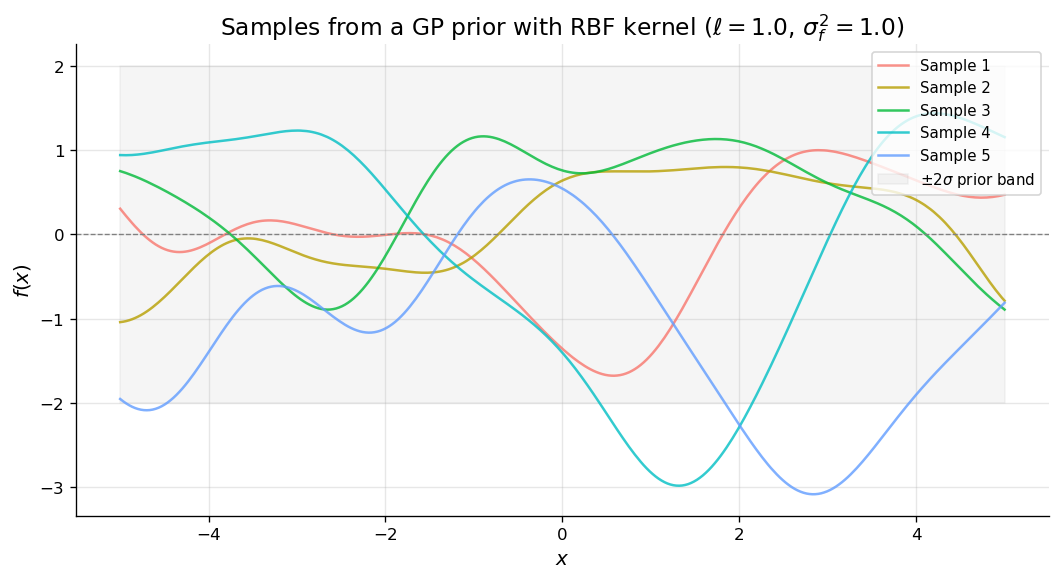

In [ ]:
def rbf_kernel(X1, X2, length_scale=1.0, signal_var=1.0):
    """Squared-exponential (RBF) kernel."""
    sq_dist = cdist(X1, X2, metric="sqeuclidean")
    return signal_var * np.exp(-0.5 * sq_dist / length_scale**2)


# Dense grid of test points
X_grid = np.linspace(-5, 5, 300).reshape(-1, 1)

# Covariance matrix under an RBF kernel with l=1
K_prior = rbf_kernel(X_grid, X_grid, length_scale=1.0, signal_var=1.0)
K_prior += 1e-8 * np.eye(len(X_grid))  # jitter for numerical stability

# Cholesky decomposition
L_prior = np.linalg.cholesky(K_prior)

# Draw 5 samples from the GP prior
n_samples = 5
Z = rng.standard_normal((len(X_grid), n_samples))
f_samples = L_prior @ Z

fig, ax = plt.subplots(figsize=(9, 5))
for i in range(n_samples):
    ax.plot(
        X_grid,
        f_samples[:, i],
        color=PALETTE[i % len(PALETTE)],
        alpha=0.8,
        label=f"Sample {i + 1}",
    )
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.fill_between(
    X_grid.ravel(), -2, 2, alpha=0.08, color="grey", label=r"$\pm 2\sigma$ prior band"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title(
    "Samples from a GP prior with RBF kernel ($\\ell = 1.0$, $\\sigma_f^2 = 1.0$)"
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Each coloured curve is a single draw from the GP prior — a *function* sampled from our distribution over functions.
Several observations:

- All samples are **smooth** and **continuous**, reflecting the infinite differentiability of the RBF kernel.
- They oscillate around zero (the prior mean).
- The grey band shows $\pm 2$ standard deviations; roughly 95% of the function values at any given $x$ lie within this band.
- Nearby points have correlated function values — the kernel ensures this.

We have not seen any data yet. These are *prior* beliefs about what the function might look like.

---

## 3. Kernel Functions — The Heart of Gaussian Processes

The kernel $k(\mathbf{x}, \mathbf{x}')$ is the single most important modelling choice in a GP.
It encodes our prior assumptions about the function we are trying to learn:
how smooth is it? Is it periodic? How quickly does correlation decay with distance?

A function $k: \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is a valid kernel if and only if,
for every finite set of inputs $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$,
the matrix $\mathbf{K}$ with entries $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ is
**symmetric positive semi-definite**.

### 3.1 Squared Exponential (RBF) kernel

$$k_{\text{SE}}(x, x') = \sigma_f^2 \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right)$$

- $\sigma_f^2$ is the **signal variance** (controls the vertical scale of the function).
- $\ell$ is the **lengthscale** (controls how quickly the correlation between function values decays with input distance).

Properties:
- Produces **infinitely differentiable** (very smooth) sample functions.
- Stationary: depends only on $|x - x'|$, not on the absolute location.
- The most commonly used kernel in practice, though its extreme smoothness is sometimes unrealistic.

### 3.2 Matérn kernel

The Matérn class introduces a parameter $\nu > 0$ that controls the smoothness of the sample functions.
The general form is:

$$k_{\text{Matérn}}(r) = \frac{\sigma_f^2\, 2^{1-\nu}}{\Gamma(\nu)} \left(\frac{\sqrt{2\nu}\, r}{\ell}\right)^\nu K_\nu\!\left(\frac{\sqrt{2\nu}\, r}{\ell}\right)$$

where $r = |x - x'|$ and $K_\nu$ is the modified Bessel function of the second kind.

Important special cases:

| $\nu$            | Smoothness                        | Name                             |
|------------------|-----------------------------------|----------------------------------|
| $1/2$            | Continuous but not differentiable | Ornstein–Uhlenbeck (exponential) |
| $3/2$            | Once differentiable               | —                                |
| $5/2$            | Twice differentiable              | —                                |
| $\nu \to \infty$ | Infinitely differentiable         | Recovers the RBF kernel          |

The closed forms for the common cases are:

$$k_{\nu=1/2}(r) = \sigma_f^2 \exp\!\left(-\frac{r}{\ell}\right)$$

$$k_{\nu=3/2}(r) = \sigma_f^2 \left(1 + \frac{\sqrt{3}\,r}{\ell}\right) \exp\!\left(-\frac{\sqrt{3}\,r}{\ell}\right)$$

$$k_{\nu=5/2}(r) = \sigma_f^2 \left(1 + \frac{\sqrt{5}\,r}{\ell} + \frac{5r^2}{3\ell^2}\right) \exp\!\left(-\frac{\sqrt{5}\,r}{\ell}\right)$$

The Matérn-$5/2$ kernel is a popular default in practice: it is smooth enough for most physical processes
but less "unrealistically smooth" than the RBF.

### 3.3 Periodic kernel

$$k_{\text{per}}(x, x') = \sigma_f^2 \exp\!\left(-\frac{2\sin^2\!\left(\pi |x - x'| / p\right)}{\ell^2}\right)$$

- $p$ is the **period**.
- $\ell$ controls the smoothness *within* each period.
- Produces functions that repeat with period $p$ — useful for seasonal data, cyclical phenomena.

### 3.4 Kernel composition

Kernels can be combined to build richer priors:

- **Sum:** $k_1 + k_2$ is a valid kernel. Useful for additive structure (e.g., smooth trend $+$ periodic component).
- **Product:** $k_1 \cdot k_2$ is a valid kernel. Useful for modulating one pattern by another (e.g., periodic function whose amplitude varies smoothly).

These closure properties follow directly from the fact that the sum and Hadamard product of PSD matrices are PSD.

The following plot compares GP prior samples under four different kernel choices.
This makes the effect of the kernel concrete: each panel shows a qualitatively different "family" of functions.

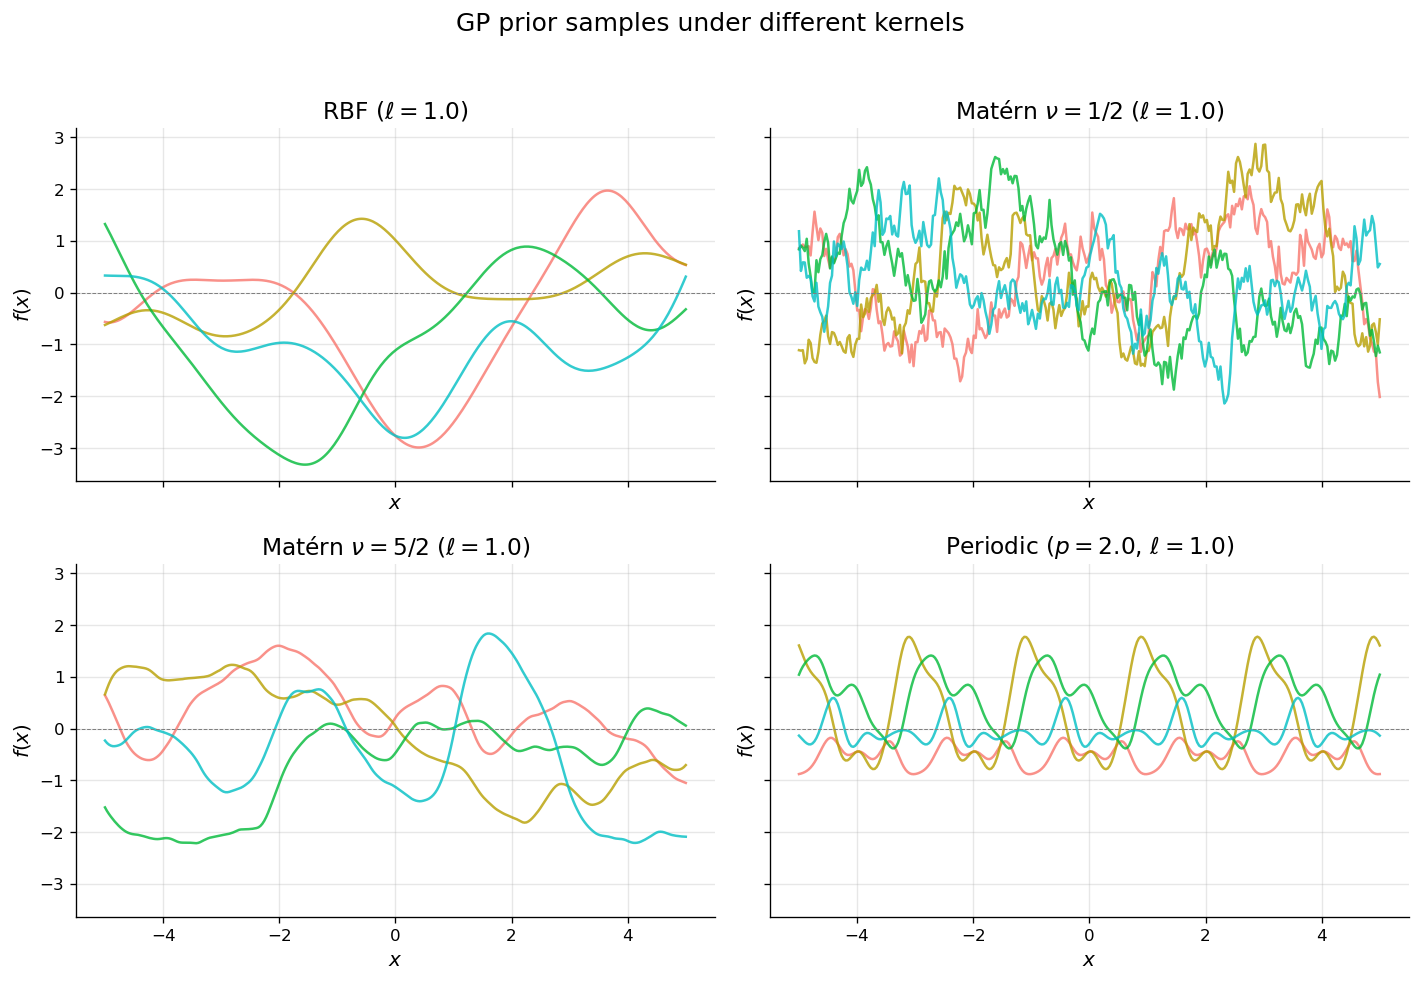

In [ ]:
def matern_kernel(X1, X2, length_scale=1.0, signal_var=1.0, nu=2.5):
    """Matern kernel for nu in {0.5, 1.5, 2.5}."""
    r = cdist(X1, X2, metric="euclidean")
    if nu == 0.5:
        return signal_var * np.exp(-r / length_scale)
    elif nu == 1.5:
        arg = np.sqrt(3) * r / length_scale
        return signal_var * (1 + arg) * np.exp(-arg)
    elif nu == 2.5:
        arg = np.sqrt(5) * r / length_scale
        return signal_var * (1 + arg + arg**2 / 3) * np.exp(-arg)
    else:
        raise ValueError(f"Only nu in {{0.5, 1.5, 2.5}} supported, got {nu}")


def periodic_kernel(X1, X2, length_scale=1.0, signal_var=1.0, period=2.0):
    """Periodic kernel."""
    r = cdist(X1, X2, metric="euclidean")
    return signal_var * np.exp(-2 * np.sin(np.pi * r / period) ** 2 / length_scale**2)


def sample_gp_prior(kernel_func, X, n_samples=3, **kwargs):
    """Draw n_samples from a GP prior defined by kernel_func."""
    K = kernel_func(X, X, **kwargs)
    K += 1e-8 * np.eye(len(X))
    L = np.linalg.cholesky(K)
    Z = rng.standard_normal((len(X), n_samples))
    return L @ Z


X_grid = np.linspace(-5, 5, 300).reshape(-1, 1)

kernels = [
    ("RBF ($\\ell=1.0$)", rbf_kernel, dict(length_scale=1.0)),
    (
        "Mat\u00e9rn $\\nu=1/2$ ($\\ell=1.0$)",
        matern_kernel,
        dict(length_scale=1.0, nu=0.5),
    ),
    (
        "Mat\u00e9rn $\\nu=5/2$ ($\\ell=1.0$)",
        matern_kernel,
        dict(length_scale=1.0, nu=2.5),
    ),
    (
        "Periodic ($p=2.0$, $\\ell=1.0$)",
        periodic_kernel,
        dict(length_scale=1.0, period=2.0),
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (title, kfunc, kw) in zip(axes.ravel(), kernels):
    samples = sample_gp_prior(kfunc, X_grid, n_samples=4, **kw)
    for i in range(4):
        ax.plot(X_grid, samples[:, i], color=PALETTE[i], alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("$f(x)$")
    ax.set_xlabel("$x$")
fig.suptitle("GP prior samples under different kernels", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Observe the qualitative differences:

- **RBF:** Very smooth, gently undulating curves.
- **Matérn $\nu = 1/2$:** Jagged, rough paths — continuous but nowhere differentiable (like Brownian motion).
- **Matérn $\nu = 5/2$:** Moderately smooth — a realistic middle ground for many physical processes.
- **Periodic:** Functions that repeat with period $p = 2$. The smoothness within each period is controlled by $\ell$.

The kernel *is* our prior belief about the function. Choosing the wrong kernel is like choosing the wrong model —
it constrains the GP to functions that may not match reality.

### Effect of the lengthscale

The lengthscale $\ell$ controls the "wiggliness" of the functions.
A small $\ell$ means that even nearby points can have very different function values (short-range correlation),
producing rapidly varying functions.
A large $\ell$ means that function values change slowly (long-range correlation),
producing gentle, broad curves.

The following plot shows GP prior samples from an RBF kernel with three different lengthscales.

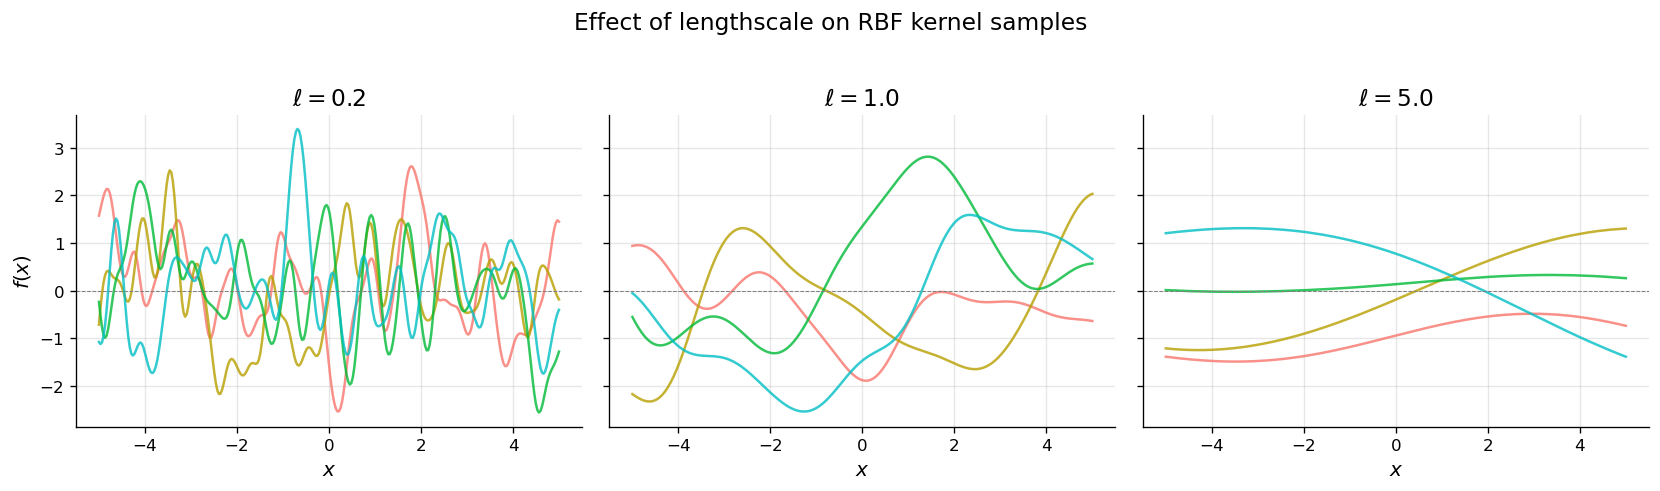

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
lengthscales = [0.2, 1.0, 5.0]

for ax, ls in zip(axes, lengthscales):
    samples = sample_gp_prior(rbf_kernel, X_grid, n_samples=4, length_scale=ls)
    for i in range(4):
        ax.plot(X_grid, samples[:, i], color=PALETTE[i], alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_title(f"$\\ell = {ls}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
fig.suptitle("Effect of lengthscale on RBF kernel samples", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 4. GP Regression — Conditioning on Data

So far we have only looked at the *prior*. The real power of GPs emerges when we **condition on observed data**
to obtain a *posterior* distribution over functions.

### Setup

Suppose we observe $n$ training pairs $(x_i, y_i)$ where

$$y_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma_n^2).$$

We place a GP prior on $f$:

$$f \sim \mathcal{GP}(0, k(\cdot, \cdot)).$$

Let $X = \{x_1, \ldots, x_n\}$ denote the training inputs, $\mathbf{y} = [y_1, \ldots, y_n]^\top$ the training outputs,
and $X_* = \{x_*^{(1)}, \ldots, x_*^{(m)}\}$ a set of test inputs at which we want to predict.

### The joint distribution

By the GP assumption, the joint distribution of the (noisy) training outputs $\mathbf{y}$
and the (noise-free) test function values $\mathbf{f}_* = [f(x_*^{(1)}), \ldots, f(x_*^{(m)})]^\top$ is:

$$\begin{bmatrix} \mathbf{y} \\ \mathbf{f}_* \end{bmatrix}
\sim \mathcal{N}\!\left(
\mathbf{0},\;
\begin{bmatrix}
\mathbf{K}(X, X) + \sigma_n^2 \mathbf{I} & \mathbf{K}(X, X_*) \\
\mathbf{K}(X_*, X) & \mathbf{K}(X_*, X_*)
\end{bmatrix}
\right)$$

where we use the shorthand $\mathbf{K}(A, B)$ for the matrix with entries $k(a_i, b_j)$.
To lighten notation, define:

- $\mathbf{K} \equiv \mathbf{K}(X, X)$ — the $n \times n$ training covariance matrix
- $\mathbf{K}_* \equiv \mathbf{K}(X, X_*)$ — the $n \times m$ cross-covariance matrix
- $\mathbf{K}_{**} \equiv \mathbf{K}(X_*, X_*)$ — the $m \times m$ test covariance matrix

### Deriving the posterior

We use the standard result for conditioning a joint Gaussian.
If $\begin{bmatrix} \mathbf{a} \\ \mathbf{b} \end{bmatrix} \sim \mathcal{N}\!\left(\begin{bmatrix} \boldsymbol{\mu}_a \\ \boldsymbol{\mu}_b \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\ \boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb} \end{bmatrix}\right)$, then

$$\mathbf{b} \mid \mathbf{a} \sim \mathcal{N}\!\left(
\boldsymbol{\mu}_b + \boldsymbol{\Sigma}_{ba} \boldsymbol{\Sigma}_{aa}^{-1}(\mathbf{a} - \boldsymbol{\mu}_a),\;
\boldsymbol{\Sigma}_{bb} - \boldsymbol{\Sigma}_{ba} \boldsymbol{\Sigma}_{aa}^{-1} \boldsymbol{\Sigma}_{ab}
\right).$$

Applying this with $\mathbf{a} = \mathbf{y}$, $\mathbf{b} = \mathbf{f}_*$, $\boldsymbol{\mu}_a = \boldsymbol{\mu}_b = \mathbf{0}$,
$\boldsymbol{\Sigma}_{aa} = \mathbf{K} + \sigma_n^2 \mathbf{I}$,
$\boldsymbol{\Sigma}_{ab} = \mathbf{K}_*$,
$\boldsymbol{\Sigma}_{ba} = \mathbf{K}_*^\top$,
$\boldsymbol{\Sigma}_{bb} = \mathbf{K}_{**}$:

$$\boxed{\mathbf{f}_* \mid X, \mathbf{y}, X_* \sim \mathcal{N}\!\left(\bar{\mathbf{f}}_*,\; \operatorname{cov}(\mathbf{f}_*)\right)}$$

where

$$\bar{\mathbf{f}}_* = \mathbf{K}_*^\top \left(\mathbf{K} + \sigma_n^2 \mathbf{I}\right)^{-1} \mathbf{y}$$

$$\operatorname{cov}(\mathbf{f}_*) = \mathbf{K}_{**} - \mathbf{K}_*^\top \left(\mathbf{K} + \sigma_n^2 \mathbf{I}\right)^{-1} \mathbf{K}_*$$

### Interpreting the posterior

These two equations are the central result of GP regression. Let us unpack them:

1. **Posterior mean** $\bar{\mathbf{f}}_*$: a weighted combination of the training targets $\mathbf{y}$,
   where the weights are determined by the kernel similarity between test and training points.
   Test points that are "close" (in kernel space) to training points receive predictions
   close to the corresponding training targets.

2. **Posterior covariance** $\operatorname{cov}(\mathbf{f}_*)$: starts from the prior covariance $\mathbf{K}_{**}$
   and *subtracts* a positive semi-definite term. This subtraction represents
   the **reduction in uncertainty** due to observing data.
   Near the training points, the subtracted term is large, so the posterior variance is small.
   Far from the training points, the subtracted term is small, so the posterior variance reverts
   to the prior variance. **Uncertainty quantification comes for free.**

3. The noise variance $\sigma_n^2$ appears only in the training-side covariance $\mathbf{K} + \sigma_n^2 \mathbf{I}$.
   It prevents the posterior mean from interpolating exactly through noisy data,
   providing natural **regularisation**.

---

## 5. From-Scratch GP Regression

We now implement GP regression in plain NumPy, following the derivation above.
For numerical stability, we avoid forming the explicit inverse $(\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1}$.
Instead, we compute the Cholesky decomposition

$$\mathbf{L} = \operatorname{chol}(\mathbf{K} + \sigma_n^2 \mathbf{I})$$

and solve triangular systems:

$$\boldsymbol{\alpha} = (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{y} \quad\Longleftrightarrow\quad \mathbf{L} \mathbf{L}^\top \boldsymbol{\alpha} = \mathbf{y}$$

which we solve in two steps: $\mathbf{L} \mathbf{v} = \mathbf{y}$, then $\mathbf{L}^\top \boldsymbol{\alpha} = \mathbf{v}$.

Similarly, for the posterior covariance:

$$\mathbf{K}_*^\top (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{K}_* = \mathbf{V}^\top \mathbf{V}, \quad \text{where } \mathbf{L}\mathbf{V} = \mathbf{K}_*.$$

This avoids the $O(n^3)$ cost of a full matrix inverse and is numerically more stable.

The cell below implements the core GP prediction function.

In [ ]:
from scipy.linalg import cho_factor, cho_solve, solve_triangular


def gp_predict(X_train, y_train, X_test, kernel_func, sigma_n=0.1, **kernel_kwargs):
    """
    GP regression from scratch.

    Parameters
    ----------
    X_train : (n, d) array of training inputs
    y_train : (n,) array of training targets
    X_test  : (m, d) array of test inputs
    kernel_func : callable(X1, X2, **kwargs) -> (n1, n2) covariance matrix
    sigma_n : observation noise standard deviation

    Returns
    -------
    mu : (m,) posterior mean at test points
    cov : (m, m) posterior covariance at test points
    """
    n = len(X_train)
    K = kernel_func(X_train, X_train, **kernel_kwargs) + sigma_n**2 * np.eye(n)
    K_s = kernel_func(X_train, X_test, **kernel_kwargs)
    K_ss = kernel_func(X_test, X_test, **kernel_kwargs)

    # Cholesky decomposition
    L = np.linalg.cholesky(K + 1e-8 * np.eye(n))

    # Solve for alpha = (K + sigma_n^2 I)^{-1} y
    alpha = cho_solve((L, True), y_train)

    # Posterior mean
    mu = K_s.T @ alpha

    # Posterior covariance
    V = solve_triangular(L, K_s, lower=True)
    cov = K_ss - V.T @ V

    return mu, cov

### Synthetic data

We generate data from a known function $f(x) = \sin(x) + 0.5\cos(3x)$ corrupted by Gaussian noise.
This lets us compare the GP predictions to the true underlying function.

In [ ]:
# --- True function and noisy observations ---
def true_function(x):
    return np.sin(x) + 0.5 * np.cos(3 * x)


sigma_noise = 0.2
n_train = 15

X_train = rng.uniform(-5, 5, size=(n_train, 1))
X_train.sort(axis=0)
y_train = true_function(X_train.ravel()) + rng.normal(0, sigma_noise, n_train)

X_test = np.linspace(-6, 6, 400).reshape(-1, 1)
f_true = true_function(X_test.ravel())

Now we apply our from-scratch GP regression. The plot below shows the posterior mean (our best prediction),
a shaded 95% credible band ($\pm 1.96\sigma$), a few posterior samples, and the true function.
Observe how the credible band narrows near the training points and widens in regions with no data.

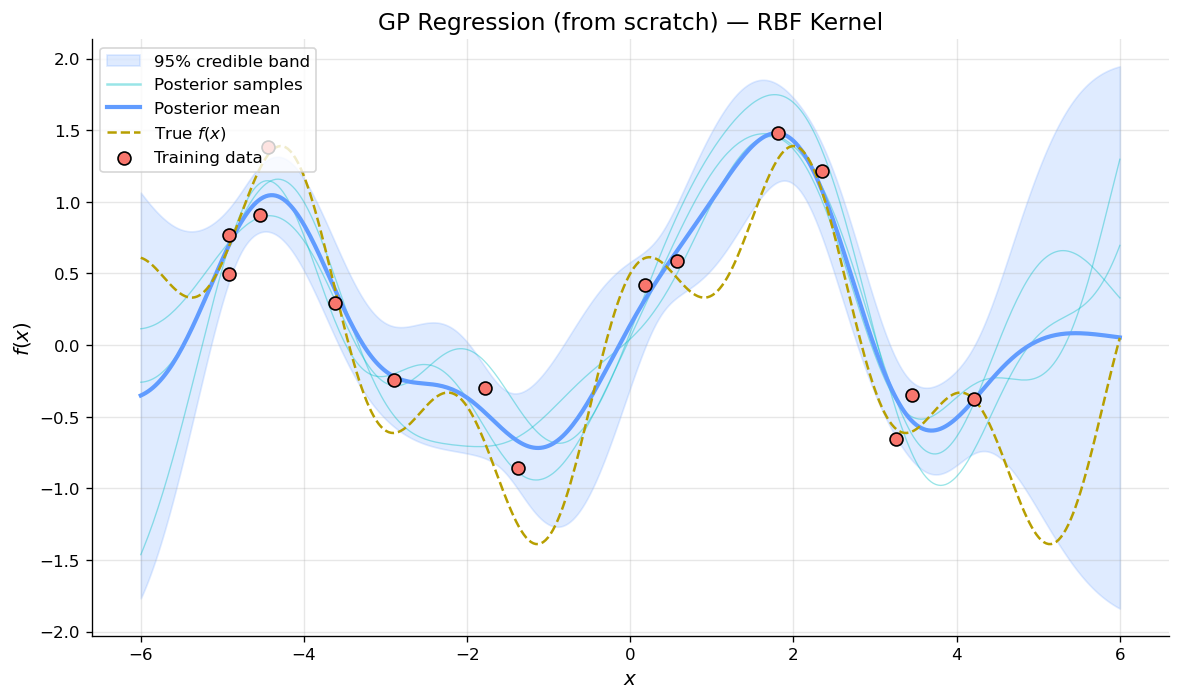

In [ ]:
# --- GP posterior with from-scratch implementation ---
mu_post, cov_post = gp_predict(
    X_train,
    y_train,
    X_test,
    rbf_kernel,
    sigma_n=sigma_noise,
    length_scale=1.0,
    signal_var=1.0,
)
std_post = np.sqrt(np.diag(cov_post))

# Draw posterior samples
L_post = np.linalg.cholesky(cov_post + 1e-8 * np.eye(len(X_test)))
Z_post = rng.standard_normal((len(X_test), 3))
f_post_samples = mu_post[:, None] + L_post @ Z_post

fig, ax = plt.subplots(figsize=(10, 6))

# Credible band
ax.fill_between(
    X_test.ravel(),
    mu_post - 1.96 * std_post,
    mu_post + 1.96 * std_post,
    alpha=0.2,
    color=PERIWINKLE,
    label="95% credible band",
)

# Posterior samples
for i in range(3):
    ax.plot(X_test, f_post_samples[:, i], color=CYAN, alpha=0.4, linewidth=0.8)
ax.plot([], [], color=CYAN, alpha=0.4, label="Posterior samples")  # legend handle

# Posterior mean
ax.plot(X_test, mu_post, color=PERIWINKLE, linewidth=2.5, label="Posterior mean")

# True function
ax.plot(X_test, f_true, color=GOLD, linewidth=1.5, linestyle="--", label="True $f(x)$")

# Training data
ax.scatter(
    X_train,
    y_train,
    color=SALMON,
    edgecolors="k",
    s=60,
    zorder=5,
    label="Training data",
)

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("GP Regression (from scratch) — RBF Kernel")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

This is a visually rich summary of everything a GP gives us:

- The **posterior mean** (solid blue) tracks the true function (dashed gold) closely in regions with data.
- The **95% credible band** (shaded region) is narrow near the training points and expands into the prior uncertainty where data is sparse.
- The **posterior samples** (light teal lines) are plausible functions consistent with the data. They agree near the observations and diverge where we are uncertain.
- At the edges ($|x| > 5$), where no training data exists, the predictions revert toward the prior mean of zero with growing uncertainty.

**This automatic, principled uncertainty quantification is the hallmark of GP regression.**

### Effect of training set size

A fundamental property of Bayesian methods is that posterior uncertainty decreases as more data is observed.
The following plot demonstrates this by fitting GPs with 3, 10, and 50 training points from the same true function.

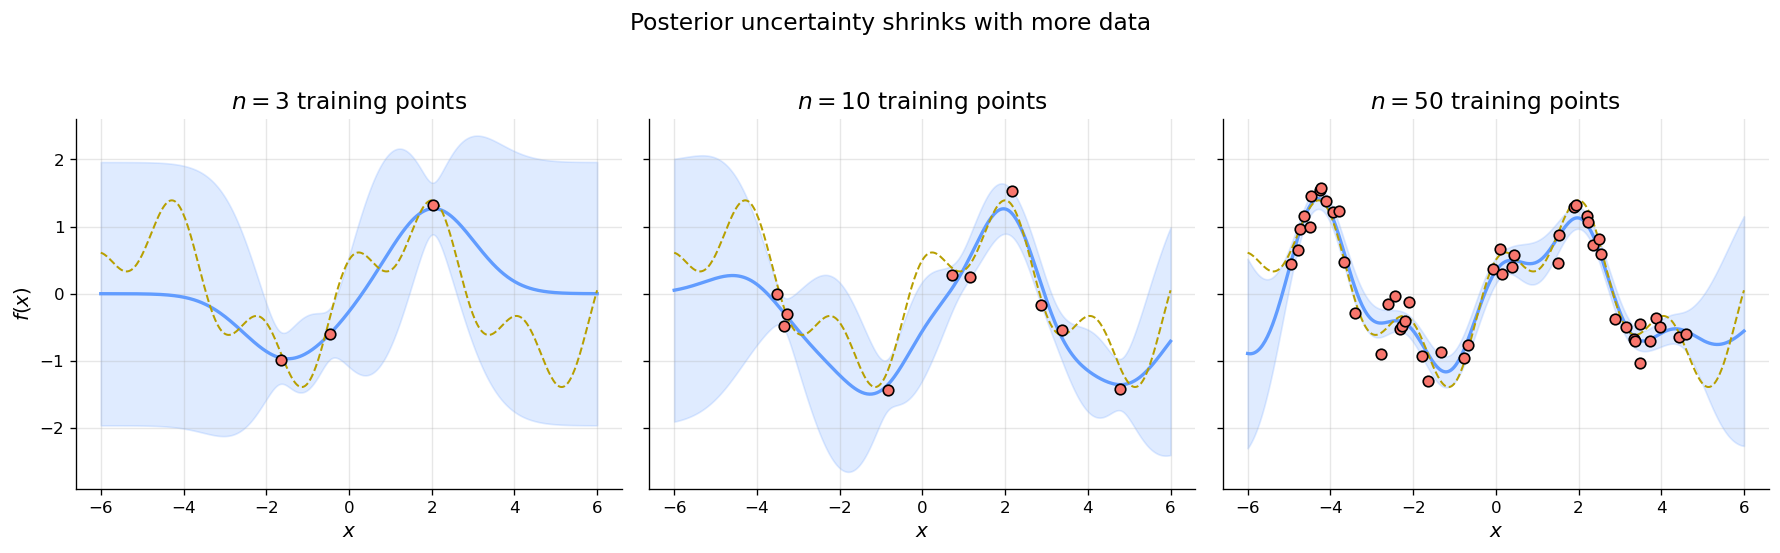

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
n_values = [3, 10, 50]

for ax, n in zip(axes, n_values):
    X_tr = rng.uniform(-5, 5, size=(n, 1))
    X_tr.sort(axis=0)
    y_tr = true_function(X_tr.ravel()) + rng.normal(0, sigma_noise, n)

    mu, cov = gp_predict(
        X_tr,
        y_tr,
        X_test,
        rbf_kernel,
        sigma_n=sigma_noise,
        length_scale=1.0,
        signal_var=1.0,
    )
    std = np.sqrt(np.diag(cov))

    ax.fill_between(
        X_test.ravel(), mu - 1.96 * std, mu + 1.96 * std, alpha=0.2, color=PERIWINKLE
    )
    ax.plot(X_test, mu, color=PERIWINKLE, linewidth=2)
    ax.plot(X_test, f_true, color=GOLD, linewidth=1.2, linestyle="--")
    ax.scatter(X_tr, y_tr, color=SALMON, edgecolors="k", s=40, zorder=5)
    ax.set_title(f"$n = {n}$ training points")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
fig.suptitle("Posterior uncertainty shrinks with more data", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

With only 3 points, the GP is highly uncertain and the credible band is wide.
With 10 points, the posterior already captures the main shape of the true function.
With 50 points, the band is very narrow and the posterior mean almost perfectly recovers $f$.
This is the Bayesian learning curve in action: more data $\Rightarrow$ less uncertainty.

---

## 6. Hyperparameter Optimisation via Marginal Likelihood

### The problem

Our GP has hyperparameters $\boldsymbol{\theta} = (\ell, \sigma_f, \sigma_n)$ embedded in the kernel and noise model.
So far we set these by hand, but in practice we want to **learn** them from data.

### The log marginal likelihood

In the Bayesian framework, the natural criterion for model selection is the **marginal likelihood**
(also called the *evidence*). It is the probability of the data under the model,
with the function $f$ integrated out:

$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \int p(\mathbf{y} \mid f, X) \, p(f \mid \boldsymbol{\theta}) \, df$$

For a GP with Gaussian likelihood, this integral is tractable and yields:

$$\log p(\mathbf{y} \mid X, \boldsymbol{\theta})
= \underbrace{-\frac{1}{2} \mathbf{y}^\top (\mathbf{K}_\theta + \sigma_n^2 \mathbf{I})^{-1} \mathbf{y}}_{\text{data fit}}
\;\underbrace{- \frac{1}{2} \log |\mathbf{K}_\theta + \sigma_n^2 \mathbf{I}|}_{\text{complexity penalty}}
\;\underbrace{- \frac{n}{2} \log 2\pi}_{\text{normalisation}}$$

This expression beautifully encodes an **automatic Occam's razor**:

- **Data fit term:** Prefers models that explain the data well (small residuals).
- **Complexity penalty:** The log-determinant penalises overly flexible models.
  A model that can fit everything is penalised because its prior probability is spread too thinly.
- These two terms trade off against each other, naturally balancing fit and complexity
  without the need for a separate validation set.

We optimise $\boldsymbol{\theta}$ by maximising $\log p(\mathbf{y} \mid X, \boldsymbol{\theta})$ using gradient-based methods.

The cell below computes the log marginal likelihood on a 2D grid of $(\ell, \sigma_f)$ values,
with $\sigma_n$ fixed at the known noise level. This surface shows the landscape that
the optimiser navigates when tuning hyperparameters.

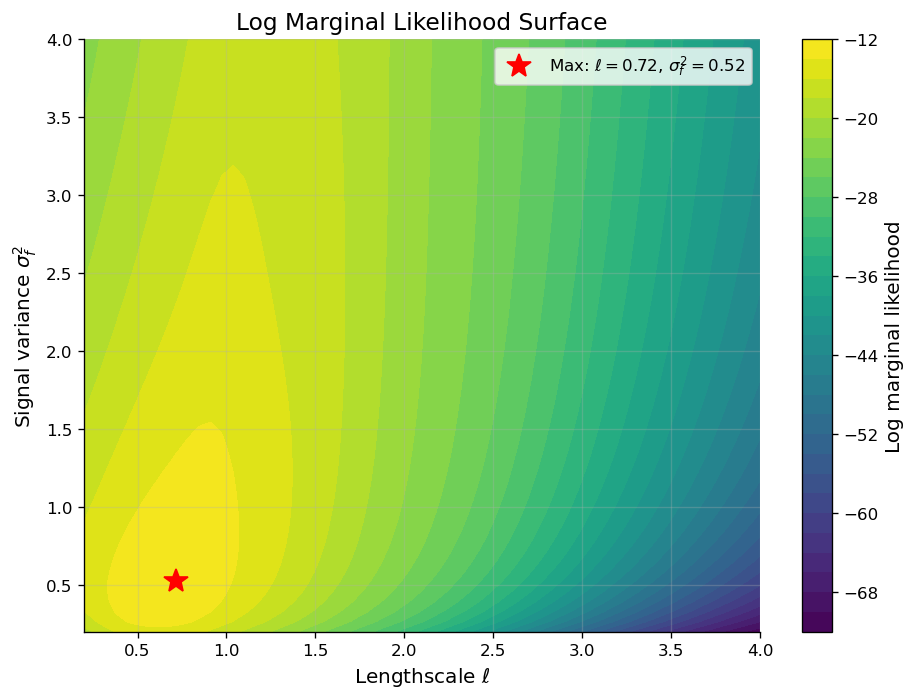

In [ ]:
def log_marginal_likelihood(X_train, y_train, kernel_func, sigma_n, **kernel_kwargs):
    """Compute the log marginal likelihood of the GP."""
    n = len(X_train)
    K = kernel_func(X_train, X_train, **kernel_kwargs) + sigma_n**2 * np.eye(n)
    K += 1e-8 * np.eye(n)
    L = np.linalg.cholesky(K)
    alpha = cho_solve((L, True), y_train)

    data_fit = -0.5 * y_train @ alpha
    complexity = -np.sum(np.log(np.diag(L)))  # = -0.5 * log|K|
    normalisation = -0.5 * n * np.log(2 * np.pi)
    return data_fit + complexity + normalisation


# Grid over (lengthscale, signal_variance)
ls_grid = np.linspace(0.2, 4.0, 60)
sv_grid = np.linspace(0.2, 4.0, 60)
LML = np.zeros((len(sv_grid), len(ls_grid)))

for i, sv in enumerate(sv_grid):
    for j, ls in enumerate(ls_grid):
        LML[i, j] = log_marginal_likelihood(
            X_train,
            y_train,
            rbf_kernel,
            sigma_n=sigma_noise,
            length_scale=ls,
            signal_var=sv,
        )

fig, ax = plt.subplots(figsize=(8, 6))
ctr = ax.contourf(ls_grid, sv_grid, LML, levels=30, cmap="viridis")
fig.colorbar(ctr, ax=ax, label="Log marginal likelihood")

# Mark the maximum
best_idx = np.unravel_index(LML.argmax(), LML.shape)
best_ls = ls_grid[best_idx[1]]
best_sv = sv_grid[best_idx[0]]
ax.plot(
    best_ls,
    best_sv,
    "r*",
    markersize=15,
    label=f"Max: $\\ell={best_ls:.2f}$, $\\sigma_f^2={best_sv:.2f}$",
)

ax.set_xlabel("Lengthscale $\\ell$")
ax.set_ylabel("Signal variance $\\sigma_f^2$")
ax.set_title("Log Marginal Likelihood Surface")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The red star marks the hyperparameter combination that maximises the log marginal likelihood.
A gradient-based optimiser would converge to this peak starting from a reasonable initialisation.

Note that the surface is smooth and typically unimodal for simple kernels,
though more complex kernel compositions can produce multimodal landscapes
requiring multiple restarts.

---

## 7. Professional Tool — scikit-learn

In practice, we rarely code GP regression from scratch.
scikit-learn's `GaussianProcessRegressor` provides a robust implementation with:

- Built-in kernel library (RBF, Matérn, White, Constant, and more)
- Automatic hyperparameter optimisation via log marginal likelihood
- Multiple restarts to avoid local optima
- Numerically stable Cholesky-based implementation

The key API pattern is:

```python
kernel = ConstantKernel() * RBF() + WhiteKernel()
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr.fit(X_train, y_train)
mu, std = gpr.predict(X_test, return_std=True)
```

The `WhiteKernel` models the observation noise $\sigma_n^2$.
The `ConstantKernel` models the signal variance $\sigma_f^2$.
All hyperparameters are optimised jointly.

The cell below fits a GP using scikit-learn on the same training data and compares
the result with our from-scratch implementation. We expect the predictions to be
essentially identical (up to differences in the optimised hyperparameters).

In [ ]:
# --- scikit-learn GP regression ---
kernel_sklearn = ConstantKernel(1.0, (1e-3, 100)) * RBF(1.0, (0.1, 10.0)) + WhiteKernel(
    0.1, (1e-5, 1.0)
)
gpr = GaussianProcessRegressor(
    kernel=kernel_sklearn, n_restarts_optimizer=10, random_state=42
)
gpr.fit(X_train, y_train)

mu_sk, std_sk = gpr.predict(X_test, return_std=True)

print("Optimised kernel:", gpr.kernel_)
print(f"Log marginal likelihood: {gpr.log_marginal_likelihood_value_:.3f}")

Optimised kernel: 0.705**2 * RBF(length_scale=0.731) + WhiteKernel(noise_level=0.0605)
Log marginal likelihood: -12.134


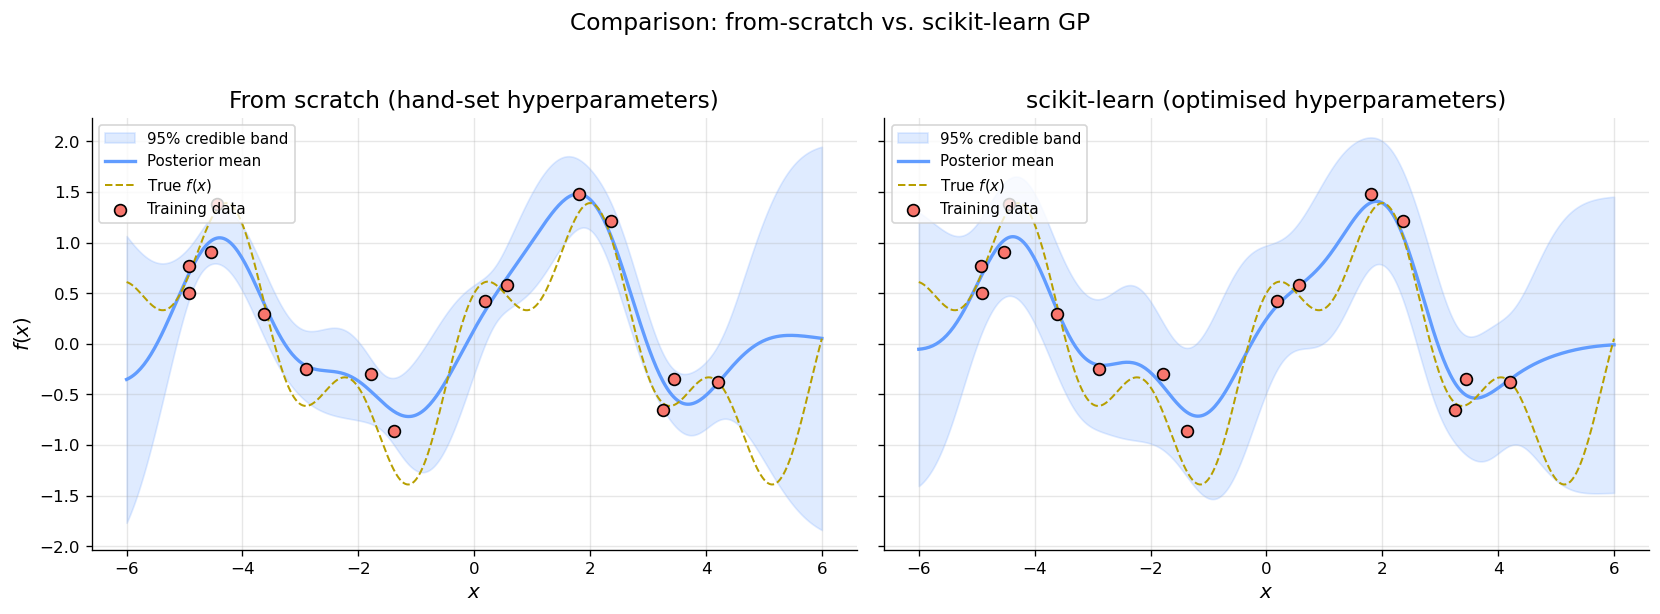

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mu_vals, std_vals, title_str in [
    (axes[0], mu_post, std_post, "From scratch (hand-set hyperparameters)"),
    (axes[1], mu_sk, std_sk, "scikit-learn (optimised hyperparameters)"),
]:
    ax.fill_between(
        X_test.ravel(),
        mu_vals - 1.96 * std_vals,
        mu_vals + 1.96 * std_vals,
        alpha=0.2,
        color=PERIWINKLE,
        label="95% credible band",
    )
    ax.plot(X_test, mu_vals, color=PERIWINKLE, linewidth=2, label="Posterior mean")
    ax.plot(
        X_test, f_true, color=GOLD, linewidth=1.2, linestyle="--", label="True $f(x)$"
    )
    ax.scatter(
        X_train,
        y_train,
        color=SALMON,
        edgecolors="k",
        s=50,
        zorder=5,
        label="Training data",
    )
    ax.set_title(title_str)
    ax.set_xlabel("$x$")
    ax.legend(fontsize=9, loc="upper left")
axes[0].set_ylabel("$f(x)$")
fig.suptitle("Comparison: from-scratch vs. scikit-learn GP", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Both implementations produce qualitatively similar results.
The scikit-learn version benefits from automatic hyperparameter optimisation:
it finds the lengthscale and signal variance that maximise the log marginal likelihood,
rather than relying on our manual choices.

In production, always prefer the library implementation for its numerical robustness,
gradient-based optimisation, and extensive testing.
The from-scratch implementation is valuable for **understanding what happens under the hood**.

---

## 8. Bayesian Optimisation Preview

One of the most impactful applications of Gaussian processes is **Bayesian optimisation** (BO).
The idea is simple and elegant:

1. We have an **expensive black-box function** $g(x)$ that we want to minimise (or maximise).
   Each evaluation costs significant time or money (e.g., running a physical experiment,
   training a deep neural network, synthesising a molecule).
2. We fit a **GP surrogate model** to the evaluations we have so far.
   The GP gives us both a prediction and an uncertainty estimate at every point.
3. We use an **acquisition function** to decide where to evaluate $g$ next.
   The acquisition function balances *exploitation* (sampling where the predicted value is good)
   with *exploration* (sampling where the uncertainty is high).
4. We evaluate $g$ at the chosen point, add it to our dataset, update the GP, and repeat.

### Expected Improvement

The most popular acquisition function is **Expected Improvement** (EI).
Let $f^+ = \max_i y_i$ be the best observation so far (for maximisation). Then:

$$\text{EI}(x) = \mathbb{E}\bigl[\max(f(x) - f^+, 0)\bigr]$$

Under the GP posterior, $f(x) \sim \mathcal{N}(\mu(x), \sigma^2(x))$, this has a closed form:

$$\text{EI}(x) = \begin{cases}
(\mu(x) - f^+)\,\Phi(Z) + \sigma(x)\,\phi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}$$

where $Z = \frac{\mu(x) - f^+}{\sigma(x)}$, and $\Phi$, $\phi$ are the standard normal CDF and PDF.

- The first term $(\mu(x) - f^+)\Phi(Z)$ favours exploitation: it is large where the predicted mean is better than $f^+$.
- The second term $\sigma(x)\phi(Z)$ favours exploration: it is large where the uncertainty is high.

EI elegantly combines both in a single scalar that can be optimised cheaply.

The following cell demonstrates one step of Bayesian optimisation on a 1D objective.
We fit a GP surrogate to a few observations, compute the EI acquisition function,
and identify the next point to evaluate.

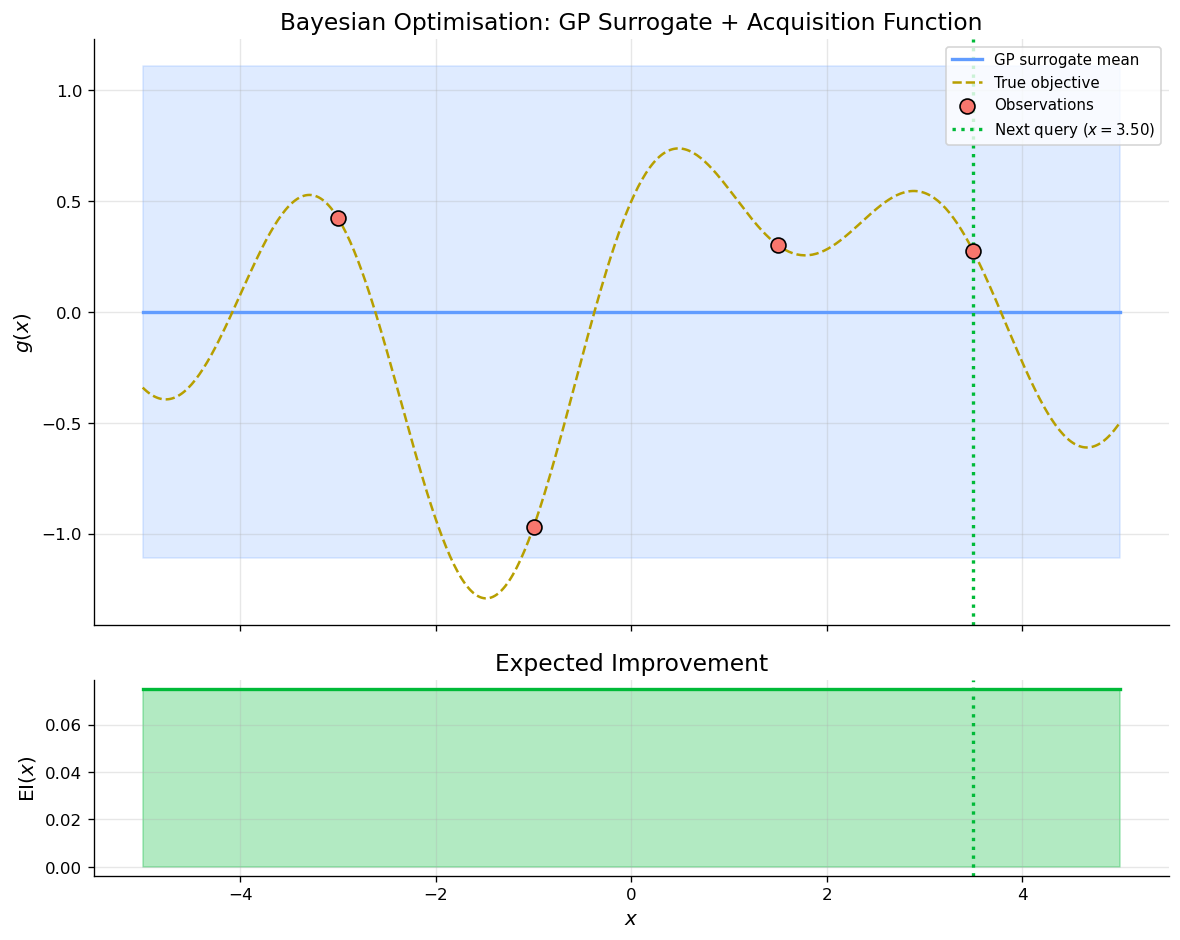

In [ ]:
# --- Simple 1D Bayesian Optimisation demo ---
def objective(x):
    """A multi-modal 1D function to maximise."""
    return np.sin(x) * np.exp(-0.1 * x**2) + 0.5 * np.cos(2 * x)


# Initial observations (few and sparse)
X_bo = np.array([-3.0, -1.0, 1.5, 3.5]).reshape(-1, 1)
y_bo = objective(X_bo.ravel())

# Fit GP surrogate
kernel_bo = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(1e-4)
gpr_bo = GaussianProcessRegressor(
    kernel=kernel_bo, n_restarts_optimizer=5, random_state=42
)
gpr_bo.fit(X_bo, y_bo)

X_dense = np.linspace(-5, 5, 500).reshape(-1, 1)
mu_bo, std_bo = gpr_bo.predict(X_dense, return_std=True)

# Expected Improvement
f_best = y_bo.max()
Z_ei = np.where(std_bo > 1e-8, (mu_bo - f_best) / std_bo, 0.0)
EI = np.where(
    std_bo > 1e-8,
    (mu_bo - f_best) * stats.norm.cdf(Z_ei) + std_bo * stats.norm.pdf(Z_ei),
    0.0,
)

next_x = X_dense[np.argmax(EI)]

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# Top: GP surrogate
ax1.fill_between(
    X_dense.ravel(),
    mu_bo - 1.96 * std_bo,
    mu_bo + 1.96 * std_bo,
    alpha=0.2,
    color=PERIWINKLE,
)
ax1.plot(X_dense, mu_bo, color=PERIWINKLE, linewidth=2, label="GP surrogate mean")
ax1.plot(
    X_dense,
    objective(X_dense.ravel()),
    color=GOLD,
    linewidth=1.5,
    linestyle="--",
    label="True objective",
)
ax1.scatter(
    X_bo, y_bo, color=SALMON, edgecolors="k", s=80, zorder=5, label="Observations"
)
ax1.axvline(
    next_x,
    color=EMERALD,
    linewidth=2,
    linestyle=":",
    label=f"Next query ($x={next_x[0]:.2f}$)",
)
ax1.set_ylabel("$g(x)$")
ax1.set_title("Bayesian Optimisation: GP Surrogate + Acquisition Function")
ax1.legend(loc="upper right", fontsize=9)

# Bottom: EI acquisition function
ax2.fill_between(X_dense.ravel(), 0, EI, alpha=0.3, color=EMERALD)
ax2.plot(X_dense, EI, color=EMERALD, linewidth=2)
ax2.axvline(next_x, color=EMERALD, linewidth=2, linestyle=":")
ax2.set_xlabel("$x$")
ax2.set_ylabel("EI$(x)$")
ax2.set_title("Expected Improvement")

plt.tight_layout()
plt.show()

The top panel shows the GP surrogate (blue) fitted to four observations (red dots),
with the true objective (dashed gold) hidden from the algorithm.
The bottom panel shows the Expected Improvement acquisition function.
Its maximum (green dotted line) indicates where we should evaluate the objective next —
a point that balances being in a promising region (high predicted mean) with being uncertain
(high posterior variance).

Bayesian optimisation is explored in depth in the digital chemistry notebook
(Module 13, Notebook 02), where we apply it to molecular property optimisation.
The key takeaway here is that GPs are not just a regression tool —
their principled uncertainty quantification makes them the backbone of **sequential experimental design**.

---

## Key Takeaways

1. **A Gaussian process is a distribution over functions.** Any finite collection of function values is jointly Gaussian. The GP is fully specified by its mean function $m(\mathbf{x})$ and kernel function $k(\mathbf{x}, \mathbf{x}')$.

2. **The kernel encodes prior assumptions** about the function: smoothness (RBF vs. Matérn), periodicity (periodic kernel), characteristic lengthscale, amplitude. Choosing the kernel is the most important modelling decision.

3. **GP regression is exact Bayesian inference.** The posterior predictive distribution is available in closed form:
   - Mean: $\bar{\mathbf{f}}_* = \mathbf{K}_*^\top (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{y}$
   - Covariance: $\operatorname{cov}(\mathbf{f}_*) = \mathbf{K}_{**} - \mathbf{K}_*^\top (\mathbf{K} + \sigma_n^2 \mathbf{I})^{-1} \mathbf{K}_*$

4. **Uncertainty quantification is automatic.** The posterior variance is small near training data and large where data is sparse. No bootstrapping or ad-hoc confidence intervals needed.

5. **Hyperparameters are tuned via the log marginal likelihood**, which provides an automatic Occam's razor balancing data fit and model complexity.

6. **GPs connect to Bayesian linear regression.** Placing a Gaussian prior on the weights of a linear model induces a GP with kernel $k(\mathbf{x}, \mathbf{x}') = \sigma_\beta^2 \boldsymbol{\phi}(\mathbf{x})^\top \boldsymbol{\phi}(\mathbf{x}')$. The GP generalises this to infinite-dimensional feature spaces via the kernel trick.

7. **The main computational bottleneck** is the $O(n^3)$ cost of the Cholesky decomposition. This limits standard GPs to datasets of a few thousand points. Sparse/inducing-point approximations can extend this to larger datasets.

8. **GPs underpin Bayesian optimisation**, where the GP's uncertainty estimates guide the search for the optimum of an expensive black-box function.

---

## Further Reading

- **Rasmussen, C. E. & Williams, C. K. I.** (2006). *Gaussian Processes for Machine Learning*. MIT Press. Freely available at [gaussianprocess.org/gpml](http://www.gaussianprocess.org/gpml/). The definitive reference.
- **MacKay, D. J. C.** (2003). *Information Theory, Inference, and Learning Algorithms*. Cambridge University Press. Chapter 45 gives a beautiful introduction to GPs.
- **Duvenaud, D.** (2014). *Automatic Model Construction with Gaussian Processes*. PhD thesis, University of Cambridge. An excellent treatment of kernel composition and structure discovery.
- **Brochu, E., Cora, V. M., & de Freitas, N.** (2010). *A Tutorial on Bayesian Optimization*. For the connection between GPs and sequential experimental design.

In [13]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
